# AdaptiveBasisAE demo

This notebook loads a synthetic data cube and a fixed source mask from
`../data/tutorial_demo.fits`, generated by `tutorial_demo_frame.ipynb`, and fits
the `comicsnet.AdaptiveBasisAE` background model.

The data cube contains a time-variable background and a moving compact
source. Each optimization step uses one complete detector frame. The model
learns reference basis images and small, frame-dependent corrections.
It reconstructs each frame as a linear combination of the modulated basis
images while excluding masked pixels from the reconstruction loss.


In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import jax
import astropy.io.fits as fits

from comicsnet import Config, AdaptiveBasisAE, fit

rcParams['image.origin'] = 'lower'
rcParams['legend.frameon'] = False

## Demo data

Load the data cube from the primary HDU and the source mask from the
`MASK` extension. Both have shape `(time, y, x)`. Mask values of 1 mark
pixels excluded from background fitting; values of 0 mark observed pixels.


In [2]:
cube = fits.open('../data/tutorial_demo.fits')[0].data
mask = fits.open('../data/tutorial_demo.fits')['MASK'].data
nz, ny, nx = cube.shape

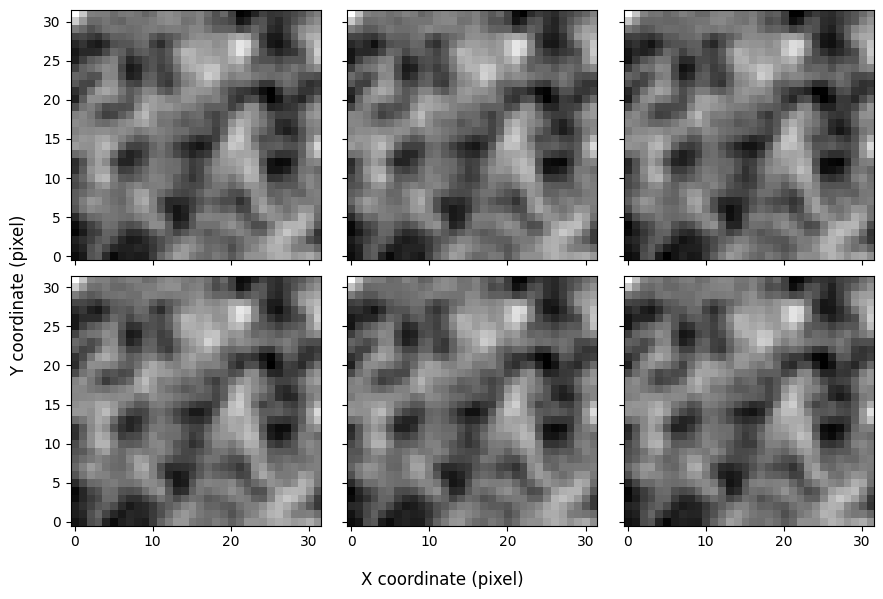

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(cube[n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit AdaptiveBasisAE with a fixed mask

Pass the source mask using `fit(model, cube, mask=mask, config=config)`.
With `update_mask=False`, this mask stays fixed throughout training and
final prediction, and is returned as `result.mask` after conversion to bool.

Internally, observation weights are `1 - mask`. As in BasisAE, the encoder
concatenates the weighted image and the weights, flattens them, and maps
them to a latent vector through a nonlinear network. This vector supplies
both signed basis coefficients and a query for each reference basis.

Single-head cross-attention compares each query with learned keys and
mixes `variation_dim` perturbation images for that basis. Softmax is
normalized over perturbation variants, not pixels or basis coefficients.
The attention output supplies a correction to each reference basis image;
the decoder combines the corrected bases to reconstruct the full frame,
including masked pixels. No frame number or time coordinate is supplied.

Perturbation parameters pass through tanh and are scaled by
`modulation_scale` times the RMS of their reference basis (floored at
1e-6). With `modulation_scale=0.1`, each pixel correction is bounded by
10% of that basis RMS, not 10% of the local pixel value. Setting this
option to zero disables modulation and uses the fixed basis decoder.

Adjust `hidden_dim` for the encoder hidden width and attention query/key
dimension, and `latent_dim` for the shared latent vector dimension.
`basis_dim` sets the number of reference bases; `variation_dim` sets the
number of perturbation variants per basis. `inner_steps` and `outer_steps`
control the number of optimization steps.
This is a deterministic AE: no KL term is used, so `beta` has no effect.


In [4]:
config = Config(
  outer_steps=5,
  inner_steps=20000,
  learning_rate=1.0e-4,
  beta=1.0e-4,
  update_mask=False,
  seed=1,
)

model_key = jax.random.PRNGKey(2)
model = AdaptiveBasisAE(
  frame_shape=(ny, nx),
  basis_dim=1,
  hidden_dim=8,
  latent_dim=4,
  variation_dim=4,
  modulation_scale=0.1,
  key=model_key,
)

result = fit(model, cube, mask=mask, config=config)

The plot shows the last 2,000 optimization steps. Each loss value is the
Gaussian negative log likelihood averaged over unmasked pixels in one
randomly selected frame, using standardized data. The fixed mask is used
at every step; the loss is not evaluated over the full data cube.


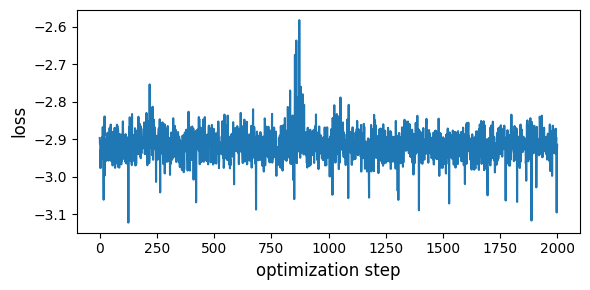

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(result.losses[-2000:])

ax.set_xlabel('optimization step', fontsize=12)
ax.set_ylabel('loss', fontsize=12)

fig.tight_layout()
plt.show()

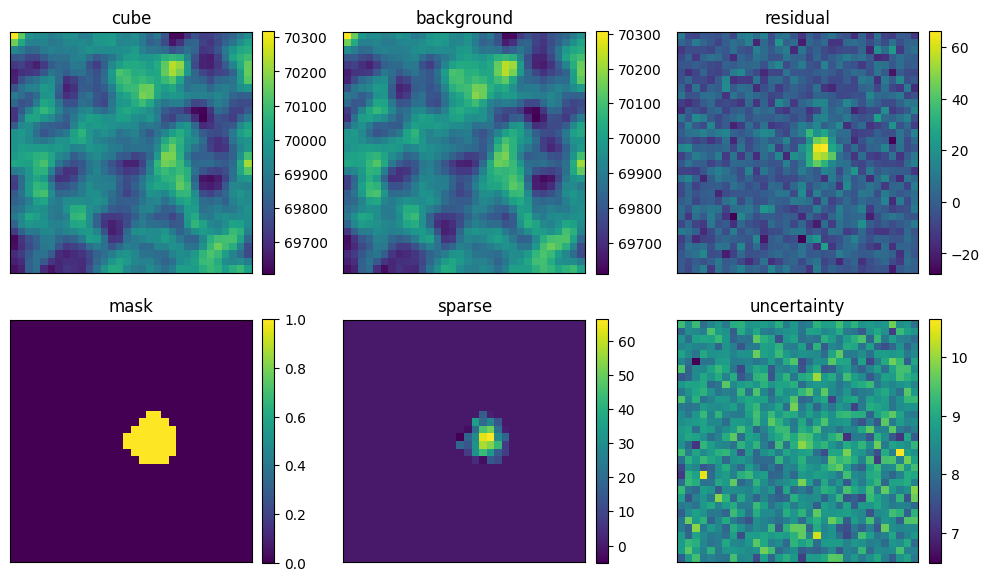

In [6]:
frame_index = 40

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
  ('cube', cube[frame_index]),
  ('background', result.background[frame_index]),
  ('residual', result.residual[frame_index]),
  ('mask', result.mask[frame_index]),
  ('sparse', result.sparse[frame_index]),
  ('uncertainty', result.uncertainty[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
  handle = axis.imshow(image, origin='lower', cmap='viridis')
  axis.set_title(title)
  axis.set_xticks([])
  axis.set_yticks([])
  fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [7]:
hdul = fits.HDUList([
  fits.PrimaryHDU(data=result.residual),
  fits.ImageHDU(data=result.background, name='MODEL'),
  fits.ImageHDU(data=result.mask.astype('int16'), name='MASK'),
  fits.ImageHDU(data=result.uncertainty, name='ERROR'),
])
hdul.writeto('../data/adaptiveBasisAE.fits', overwrite=True)

## Reference basis

The plots show the learned common bias and the first reference basis in
the model's standardized units. These are shared across frames; the basis
shown here does not include the frame-dependent attention correction.


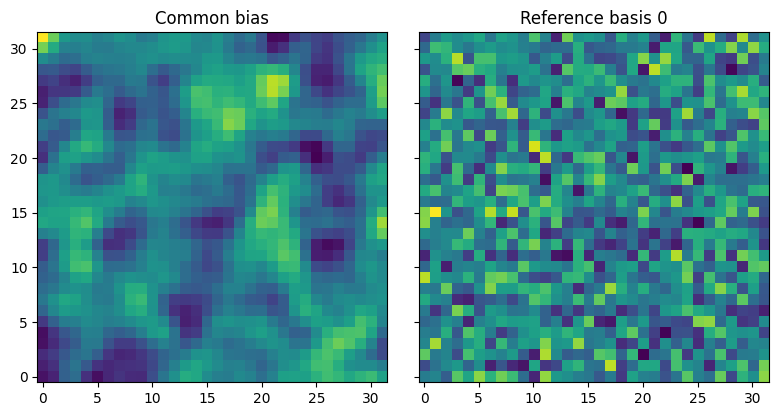

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(result.model.bias)
axes[0].set_title('Common bias')
axes[1].imshow(result.model.basis[0])
axes[1].set_title('Reference basis 0')

fig.tight_layout()
plt.show()